#### **1. Introdução**
Explorar fatores que influenciam o desempenho acadêmico dos alunos, considerando aspectos socioeconômicos, hábitos de estudo e frequência.

#### **2. Importação das Bibliotecas**


In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid", palette="colorblind")


#### **3. Importação do Dataset**


In [47]:
df = pd.read_csv("./Student_Performance.csv")
df.head()

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f


#### **4. Visão Geral**

In [48]:
df.shape


(25000, 16)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             25000 non-null  int64  
 1   age                    25000 non-null  int64  
 2   gender                 25000 non-null  object 
 3   school_type            25000 non-null  object 
 4   parent_education       25000 non-null  object 
 5   study_hours            25000 non-null  float64
 6   attendance_percentage  25000 non-null  float64
 7   internet_access        25000 non-null  object 
 8   travel_time            25000 non-null  object 
 9   extra_activities       25000 non-null  object 
 10  study_method           25000 non-null  object 
 11  math_score             25000 non-null  float64
 12  science_score          25000 non-null  float64
 13  english_score          25000 non-null  float64
 14  overall_score          25000 non-null  float64
 15  fi

In [50]:
df.drop(columns="student_id").describe()

,age,study_hours,attendance_percentage,math_score,science_score,english_score,overall_score
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,16.482760,4.253224,75.084084,63.785944,63.745320,63.681948,64.006172
std,1.703895,2.167541,14.373171,20.875262,20.970529,20.792693,18.932025
min,14.000000,0.500000,50.000000,0.000000,0.000000,0.000000,14.500000
25%,15.000000,2.400000,62.800000,48.300000,48.200000,48.300000,49.000000
50%,16.000000,4.300000,75.100000,64.100000,64.100000,64.200000,64.200000
75%,18.000000,6.100000,87.500000,80.000000,80.000000,80.000000,79.000000
max,19.000000,8.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [51]:
print(df.nunique())
print("-----------------------------------------------")
categoricas = df.nunique()[df.nunique() < 5].index
print("Categóricas:", categoricas.to_list())

student_id               15000
age                          6
gender                       3
school_type                  2
parent_education             6
study_hours                 76
attendance_percentage      501
internet_access              2
travel_time                  4
extra_activities             2
study_method                 6
math_score                 906
science_score              907
english_score              904
overall_score              808
final_grade                  6
dtype: int64
-----------------------------------------------
Categóricas: ['gender', 'school_type', 'internet_access', 'travel_time', 'extra_activities']


#### **5. Limpeza dos Dados**

In [52]:
df.isnull().sum()

student_id               0
age                      0
gender                   0
school_type              0
parent_education         0
study_hours              0
attendance_percentage    0
internet_access          0
travel_time              0
extra_activities         0
study_method             0
math_score               0
science_score            0
english_score            0
overall_score            0
final_grade              0
dtype: int64

In [53]:
df.duplicated().sum()

np.int64(10000)

In [54]:
df = df.drop_duplicates()
df.shape


(15000, 16)

#### **6. Análise Univariada**

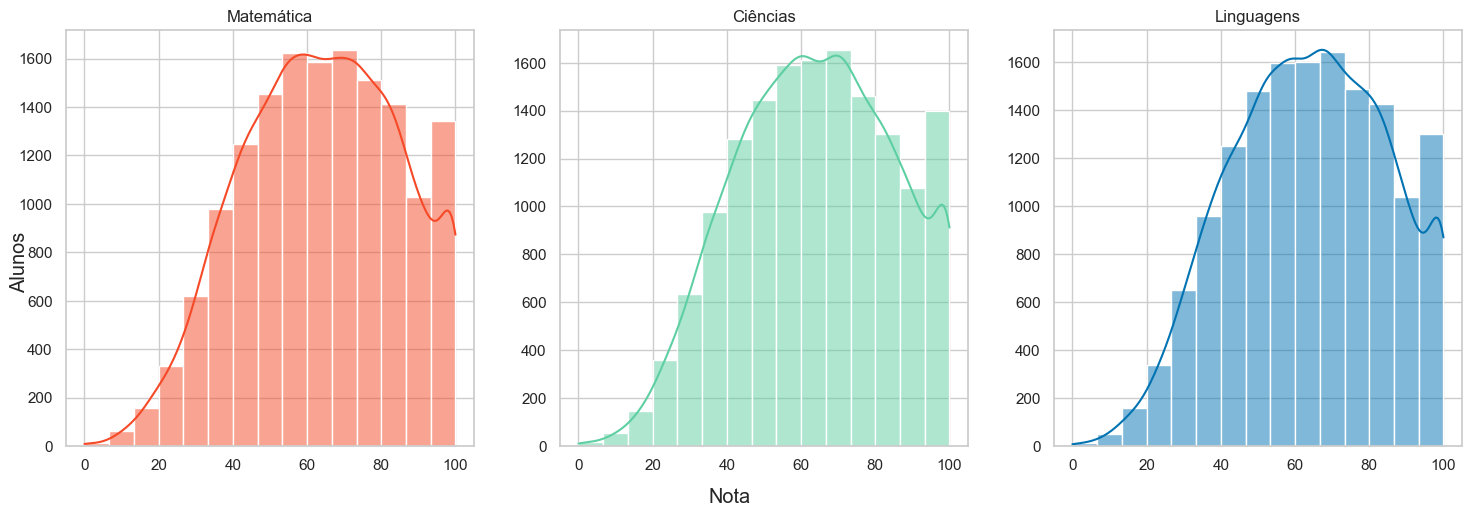

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

sns.histplot(
    df["math_score"],bins=15, color="#F54927", kde=True, ax=axes[0]
)

sns.histplot(
    df["science_score"],bins=15, color="#5ECFA2", kde=True, ax=axes[1]
)

sns.histplot(
    df["english_score"],bins=15, kde=True, ax=axes[2]
)

plt.tight_layout()

axes[0].set_title("Matemática")
axes[1].set_title("Ciências")
axes[2].set_title("Linguagens")

for ax in axes:
    ax.set_ylabel("")
    ax.set_xlabel("")

fig.supxlabel("Nota")
fig.supylabel("Alunos")

plt.show()

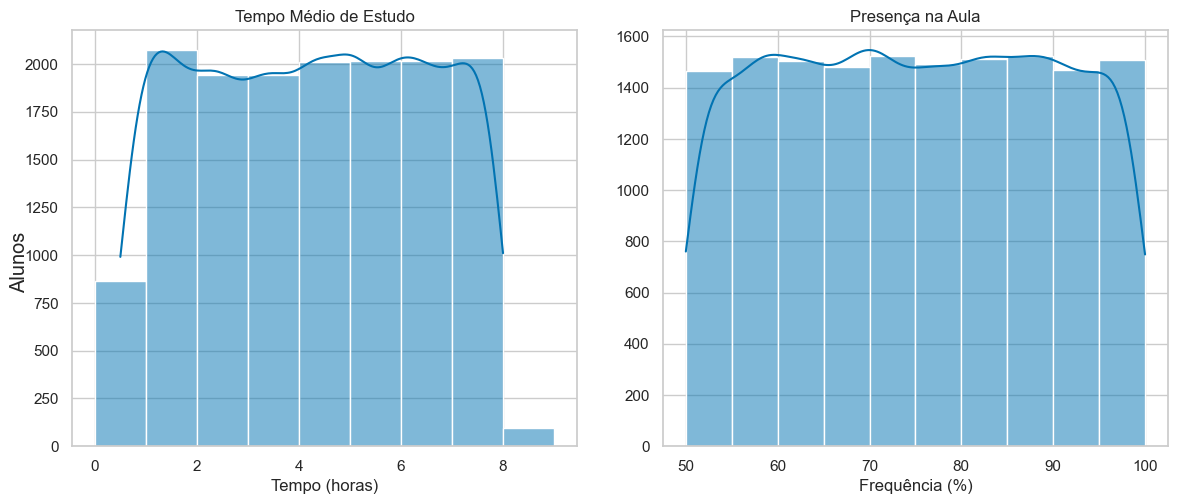

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))


sns.histplot(df["study_hours"], discrete=True, kde=True, ax=axes[0])
sns.histplot(df["attendance_percentage"],kde=True, bins=10)

plt.tight_layout()

fig.supylabel("Alunos")

axes[0].set_title("Tempo Médio de Estudo")
axes[0].set_xlabel("Tempo (horas)")
axes[1].set_title("Presença na Aula")
axes[1].set_xlabel("Frequência (%)")

for ax in axes:
  ax.set_ylabel("")


plt.show()

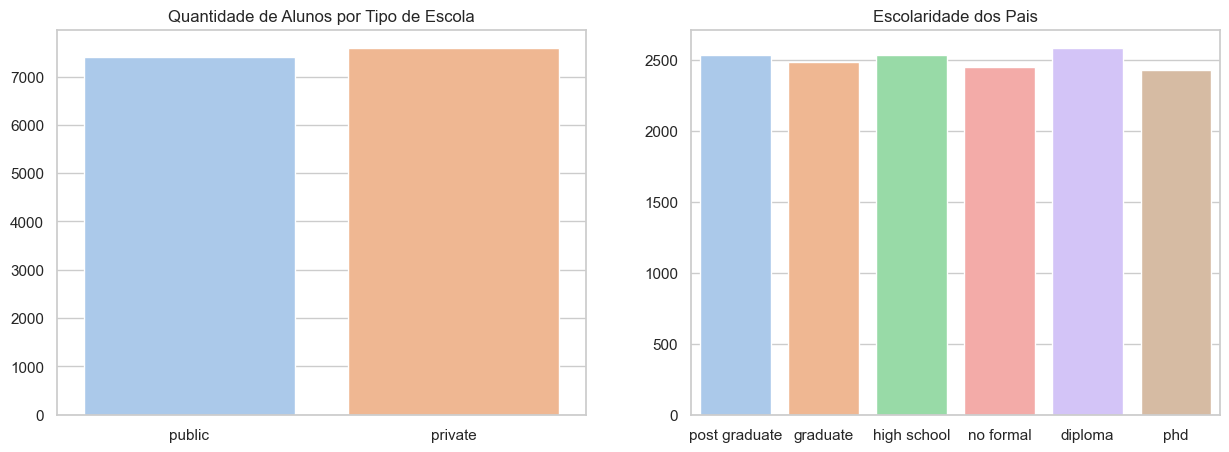

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))
sns.countplot(
    x=df["school_type"],
    hue=df["school_type"],
    palette="pastel",
    ax=axes[0],
)
sns.countplot(
    x=df["parent_education"],
    hue=df["parent_education"],
    palette="pastel",
    ax=axes[1],
)

axes[0].set_title("Quantidade de Alunos por Tipo de Escola")
axes[1].set_title("Escolaridade dos Pais")


for ax in axes:
  ax.set_ylabel("")
  ax.set_xlabel("")

plt.show()

#### **6. Análise Bivariada**

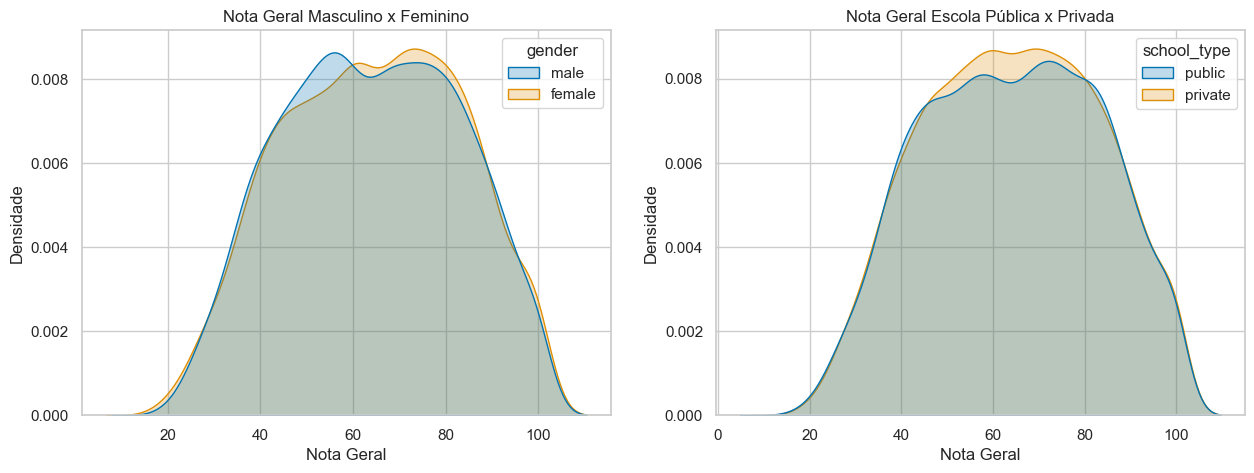

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))
df_gender = df[df["gender"].isin(["male", "female"])]

sns.kdeplot(data=df_gender, x="overall_score", hue="gender", fill=True, ax=axes[0])
sns.kdeplot(data=df, x="overall_score",hue="school_type", fill=True, ax=axes[1] )

axes[0].set_title("Nota Geral Masculino x Feminino")
axes[1].set_title("Nota Geral Escola Pública x Privada")

for ax in axes:
  ax.set_xlabel("Nota Geral")
  ax.set_ylabel("Densidade")

plt.show()

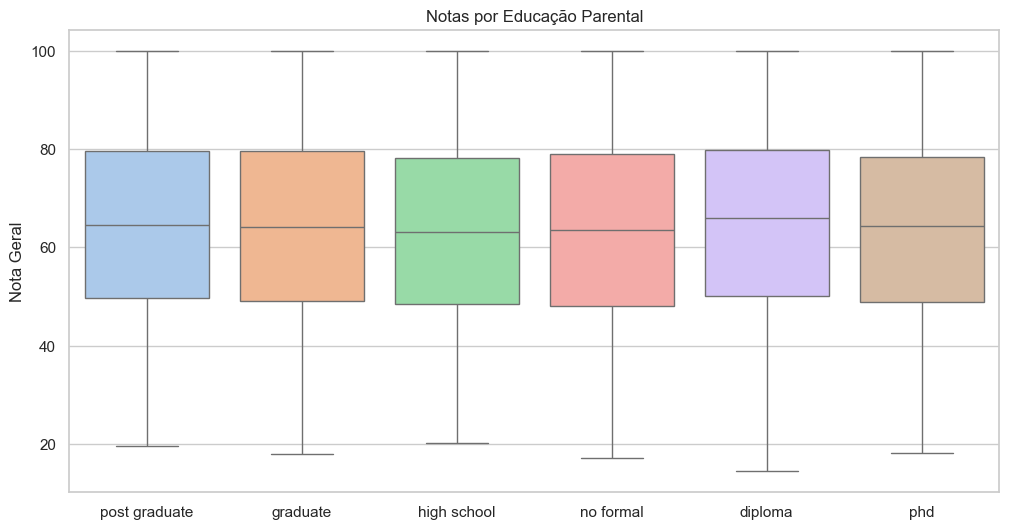

In [106]:

plt.figure(figsize=(12,6))
sns.boxplot(
    data=df,
    x="parent_education",
    y="overall_score",
    palette="pastel",
    hue="parent_education"
)
plt.title("Notas por Educação Parental")
plt.ylabel("Nota Geral")
plt.xlabel("")
plt.show()

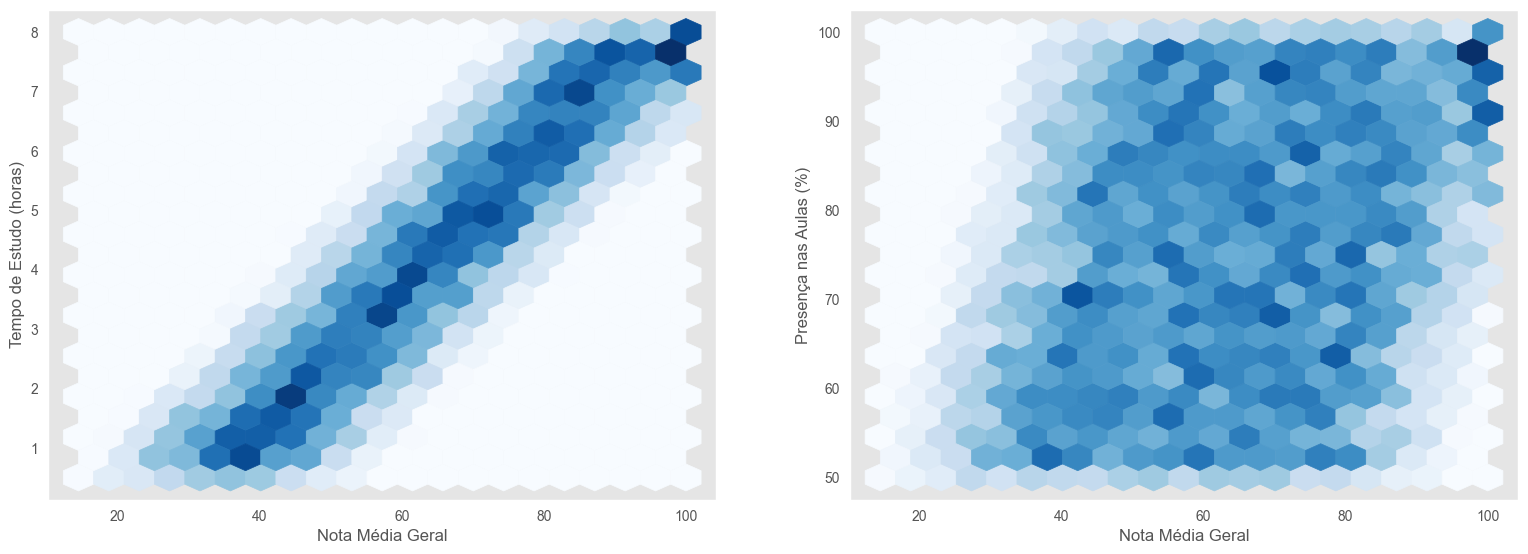

In [ ]:
plt.style.use('_mpl-gallery-nogrid')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hexbin(df["overall_score"],df["study_hours"], gridsize=20)
axes[1].hexbin( df["overall_score"], df["attendance_percentage"], gridsize=20)

axes[0].set_xlabel("Nota Média Geral")
axes[0].set_ylabel("Tempo de Estudo (horas)")
axes[1].set_xlabel("Nota Média Geral")
axes[1].set_ylabel("Presença nas Aulas (%)")

plt.show()